<a href="https://colab.research.google.com/github/Alan-O-R/CP-02---Renovaveis/blob/main/AULA_07_Regress%C3%A3o_Linear_com_Dados_de_Energia_(2)_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Checkpoint 2 – Regressão Linear e Estabilidade da Rede Elétrica

Esta atividade faz parte do **Checkpoint 2**. O objetivo é construir e comparar dois modelos de Regressão Linear para prever o valor numérico da coluna `stab`, relacionada à estabilidade da rede elétrica.

Ao finalizar, salve este notebook no formato `.ipynb` e faça o upload no **repositório GitHub da atividade criado anteriormente**. Mantenha todas as células executadas, os resultados visíveis e as respostas preenchidas.

##Participantes:
####Nome: Gabriel de Paula Santos - RM: 573195
####Nome: Alan Otalvaro - RM: 571794
####Nome: Joao Lucas Silva Lopes - RM : 573875
####Nome: joao Pedro ribeiro santos - RM : 570562
####Nome: Joao Pedro Evangelista - RM : 573899
####Nome: Enzo Ribeiro - RM : 569429

## 1. Importação das bibliotecas

Importe as bibliotecas necessárias para manipulação e visualização dos dados, separação entre treino e teste, criação do modelo de Regressão Linear e cálculo das métricas R², MAE e MSE.

In [ ]:
# Importe aqui as bibliotecas necessárias
# Manipulação de tabelas e matrizes
import pandas as pd
import numpy as np
# Graficos
import matplotlib.pyplot as plt
import seaborn as sns
# Algoritmo de regreção linear
from sklearn.linear_model import LinearRegression
# Ferramenta para separaçãoi de dados e testes
# X_train , X_test, Y_train, Y_test
from sklearn.model_selection import train_test_split
# Avaliação com acuracia e matriz de confusão
from sklearn.metrics import accuracy_score, confusion_matrix
# metricas de regressão
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## 2. Carregamento e análise inicial do dataset

Carregue o arquivo CSV do conjunto **Electrical Grid Stability** em um DataFrame chamado `df`. Depois:

- visualize as primeiras linhas;
- verifique a quantidade de linhas e colunas;
- apresente os nomes e os tipos das colunas;
- verifique se existem valores ausentes;
- apresente as estatísticas descritivas das variáveis numéricas.

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_1CCPH_SERS/refs/heads/main/Data_for_UCI_named.csv')
df.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


In [ ]:
linhas = df.shape[0]
colunas = df.shape[1]
print(f"Linhas: {linhas}")
print(f"Colunas: {colunas}")

Linhas: 10000
Colunas: 14


In [ ]:
print(f"Nomes das colunas:")
for i in df.columns:
  print(i,end=", ")

Nomes das colunas:
tau1, tau2, tau3, tau4, p1, p2, p3, p4, g1, g2, g3, g4, stab, stabf, 

In [ ]:
if df.isnull().sum().sum() == 0:
  print("Não existem valores ausentes")
else:
  print("Existem valores ausentes")

Não existem valores ausentes


In [ ]:
df.describe(include='object')

,stabf
count,10000
unique,2
top,unstable
freq,6380


### Registro da análise inicial

**Quantidade de linhas: 10000**  
**Quantidade de colunas: 14**  
**Existem valores ausentes? Negativo**  
**Observações importantes sobre o dataset:**
*   A coluna `stabf` é uma variável categórica que descreve o estado de estabilidade ('unstable' ou 'stable'), com 'unstable' sendo o mais frequente. Esta coluna é uma versão categorizada da variável numérica `stab`, que é o alvo para a regressão.

## 3. Definição da variável target

A variável que os modelos deverão prever é a coluna `stab`. Crie a variável `y` com essa coluna e apresente seus primeiros valores.

In [ ]:
# Crie a variável y usando a coluna stab
y = df['stab']
y.head()

,stab
0,0.055347
1,-0.005957
2,0.003471
3,0.028871
4,0.049860


In [ ]:
dados = df.drop(columns=['stabf'])
dados.head()


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860


## 4. Matriz de correlação

Calcule a matriz de correlação das variáveis numéricas e crie um mapa de calor (*heatmap*). Em seguida, identifique as **cinco variáveis com maior correlação absoluta com `stab`**, sem considerar a própria coluna `stab`.

Considere também correlações negativas: quanto mais próximo de +1 ou -1, maior é a intensidade da relação linear.

In [ ]:
from pandas.core.arrays.categorical import contains
correlacoes_com_stab = dados.corr()['stab'].drop('stab')
correlacoes_abs = correlacoes_com_stab.abs().sort_values(ascending=False)
cinco_miores_correlacoes = correlacoes_abs.head(5)
print("As cinco variáveis com maior correlação absoluta com 'stab' são:")
print(cinco_miores_correlacoes)


As cinco variáveis com maior correlação absoluta com 'stab' são:
g3      0.308235
g2      0.293601
tau2    0.290975
g1      0.282774
tau3    0.280700
Name: stab, dtype: float64


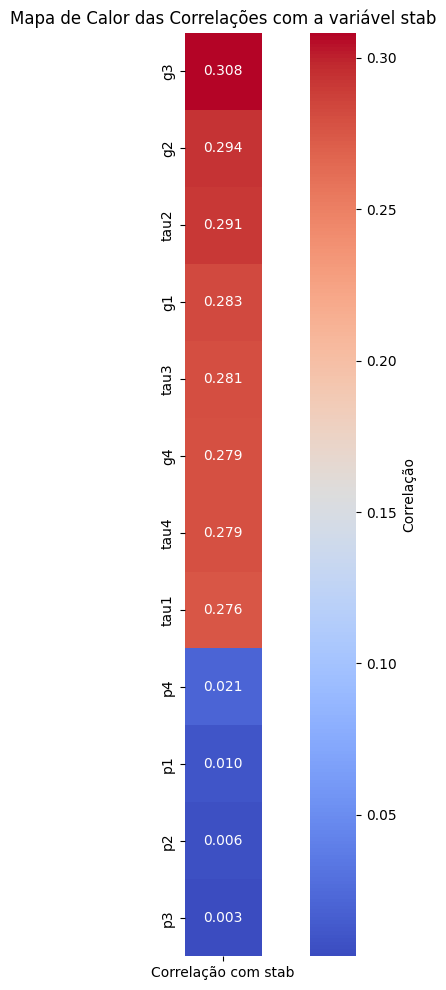

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
correlacoes_df = correlacoes_abs.to_frame(name='Correlação com stab')
sns.heatmap(correlacoes_df, fmt='.3f',square=True ,annot=True,cmap="coolwarm", cbar_kws={'label': 'Correlação'});
plt.title('Mapa de Calor das Correlações com a variável stab')
plt.tight_layout()
plt.show()

## 5. Apoio do Gemini para seleção e visualização das variáveis

Depois de criar a matriz de correlação, use o Gemini no Google Colab com o prompt abaixo. Analise o código sugerido antes de executá-lo e faça os ajustes necessários.

> Tenho um DataFrame Pandas chamado `df` com dados do Electrical Grid Stability. A variável target é a coluna `stab`. Gere um código Python que: (1) calcule a correlação das variáveis numéricas com `stab`; (2) desconsidere a própria coluna `stab`; (3) use o valor absoluto das correlações para identificar as cinco variáveis com maior correlação com `stab`; (4) apresente os nomes das cinco variáveis e os valores originais de correlação, preservando os sinais positivo ou negativo; (5) armazene os nomes dessas variáveis em uma lista chamada `cinco_variaveis`; e (6) crie cinco gráficos de dispersão, um para cada variável selecionada, usando a variável no eixo X e `stab` no eixo Y. Utilize Pandas, Matplotlib e Seaborn. O DataFrame `df` já está carregado.

In [ ]:
cinco_variaveis = []
for var, abs_corr in cinco_miores_correlacoes.items():
    original_corr = correlacoes_com_stab[var]
    print(f"Variavel: {var}, correlação Original: {original_corr:.4f}")
    cinco_variaveis.append(var)

print(f"\nLista 'cinco_variaveis': {cinco_variaveis}")


Variavel: g3, correlação Original: 0.3082
Variavel: g2, correlação Original: 0.2936
Variavel: tau2, correlação Original: 0.2910
Variavel: g1, correlação Original: 0.2828
Variavel: tau3, correlação Original: 0.2807

Lista 'cinco_variaveis': ['g3', 'g2', 'tau2', 'g1', 'tau3']


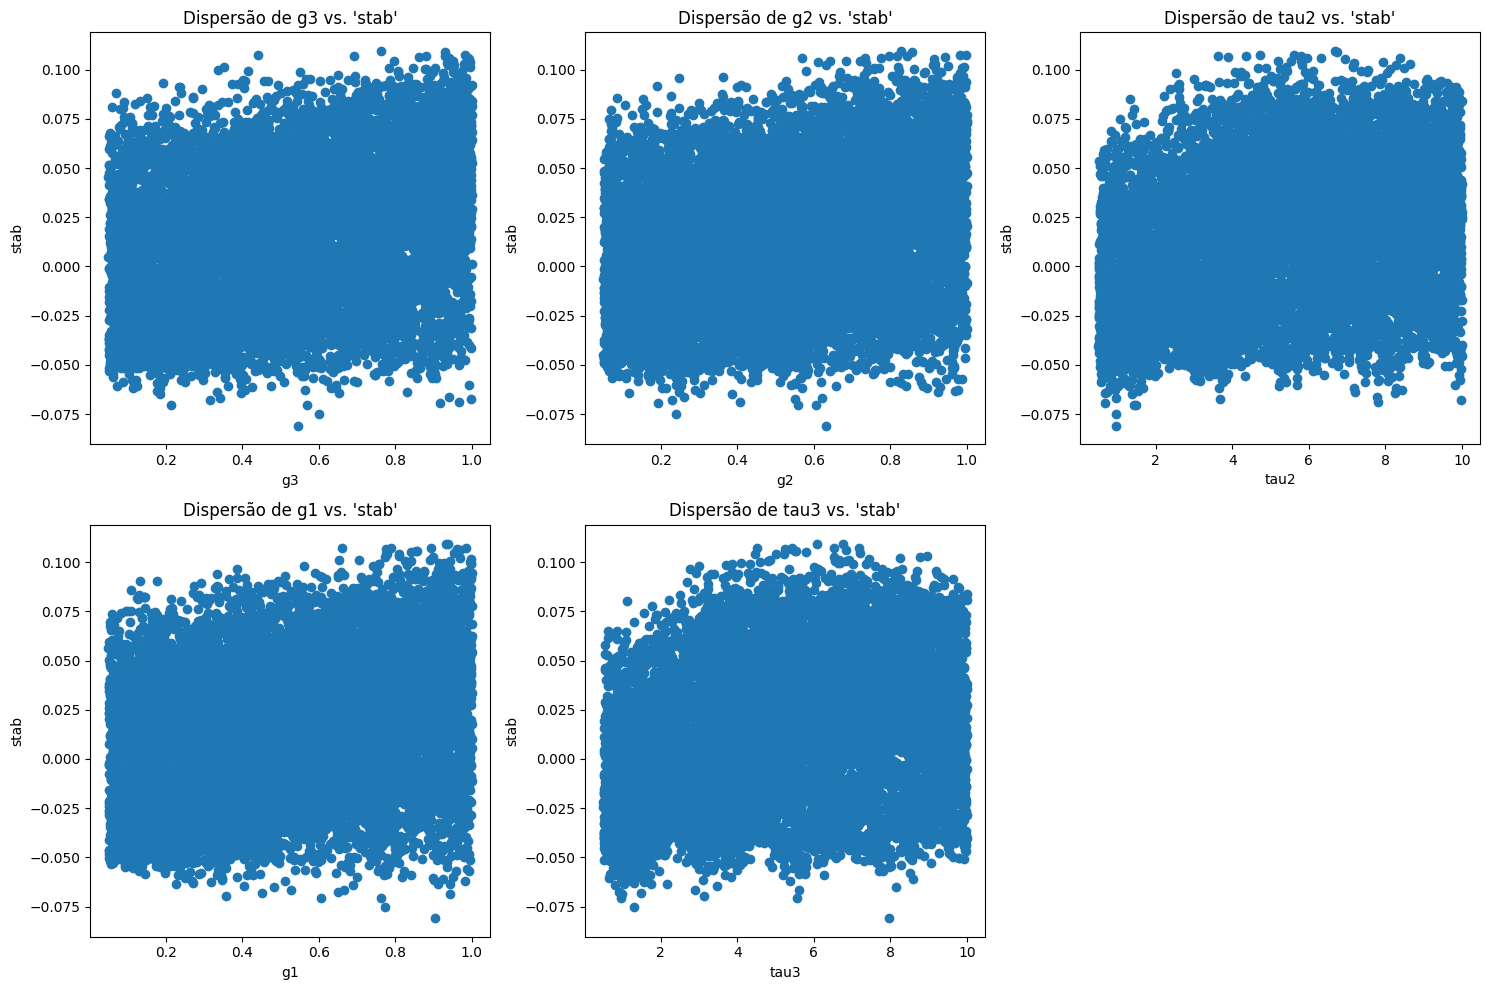

In [ ]:
plt.figure(figsize=(15, 10))
for i, var in enumerate(cinco_variaveis):
    plt.subplot(2, 3, i + 1)
    plt.scatter(x = dados[var], y = dados['stab'])
    plt.title(f"Dispersão de {var} vs. 'stab'")
    plt.xlabel(var)
    plt.ylabel('stab')
plt.tight_layout()
plt.show()

### Variáveis selecionadas

| Posição | Variável | Correlação original com `stab` |
|---:|---|---:|
| 1 | g3 | 0.3082 |
| 2 | g2 | 0.2936 |
| 3 | tau2 | 0.2910 |
| 4 | g1 | 0.2828 |
| 5 | tau3 | 0.2807 |

**Qual variável apresentou a maior correlação absoluta com `stab`?**  
Resposta: A variável `g3` apresentou a maior correlação absoluta com `stab`, com um valor de 0.3082.

**O que os gráficos de dispersão indicam sobre as relações entre essas variáveis e `stab`?**  
Resposta: Os gráficos de dispersão indicam uma relação linear fraca ou moderada entre as variáveis selecionadas e `stab`. Embora haja uma concentração de pontos, eles estão bastante espalhados, mostrando uma variabilidade considerável, o que é esperado para correlações que não são extremamente altas.

# Modelo 1 – Cinco maiores correlações

Crie o DataFrame `X` utilizando somente as cinco variáveis selecionadas a partir da matriz de correlação. A variável `y` deve continuar sendo a coluna `stab`.

In [ ]:
# Crie X com as cinco variáveis selecionadas
X = dados[cinco_variaveis]

# Mostre as primeiras linhas de X e y
display(X.head())
display(y.head())

,g3,g2,tau2,g1,tau3
0,0.887445,0.859578,3.079885,0.650456,8.381025
1,0.562139,0.862414,4.902524,0.413441,3.047541
2,0.839444,0.766689,8.848428,0.163041,3.046479
3,0.929381,0.976744,7.669600,0.446209,4.486641
4,0.656947,0.455450,7.608772,0.797110,4.943759


,stab
0,0.055347
1,-0.005957
2,0.003471
3,0.028871
4,0.049860


## 6. Separação entre treino e teste

Separe `X` e `y` utilizando 80% dos dados para treinamento e 20% para teste, com `random_state=42`. Use os nomes `X_treino`, `X_teste`, `y_treino` e `y_teste`. Apresente a quantidade de registros em cada conjunto.

In [ ]:
X_treino, X_teste = train_test_split( X, test_size=0.2,random_state=42)
y_treino, y_teste = train_test_split( y, test_size=0.2,random_state=42)

display(X_treino.head() , X_teste.head())
print("===" * 18 )
display(y_treino.head() , y_teste.head())

,g3,g2,tau2,g1,tau3
9254,0.792247,0.612514,8.255999,0.166933,8.109960
1561,0.420697,0.772031,0.781086,0.740131,5.556240
1670,0.302983,0.601201,8.891698,0.850271,1.778212
6087,0.444109,0.686392,8.461652,0.961836,8.675216
6669,0.457295,0.680618,4.061263,0.217076,6.192641


,g3,g2,tau2,g1,tau3
6252,0.433606,0.934229,9.692422,0.487235,6.570391
4684,0.911199,0.772211,9.423079,0.395106,1.424423
1731,0.897505,0.175994,1.341172,0.162310,7.986504
4742,0.061032,0.573440,2.311770,0.053894,4.410704
4521,0.437366,0.753533,3.742481,0.100005,8.975171


,stab
9254,0.063720
1561,-0.047254
1670,0.014128
6087,0.024980
6669,0.050475


,stab
6252,0.035629
4684,0.002383
1731,0.030620
4742,-0.021962
4521,-0.039032


## 7. Treinamento e previsões do Modelo 1

Crie um modelo de Regressão Linear chamado obrigatoriamente `modeloLR`. Treine o modelo e gere as previsões do conjunto de teste em uma variável chamada `y_previsao_1`.

In [ ]:


modeloLR = LinearRegression()

modeloLR.fit(X_treino, y_treino)

y_previsao_1 = modeloLR.predict(X_teste)




## 8. Métricas do Modelo 1

Calcule R², MAE e MSE. Armazene os resultados nas variáveis `r2_modelo_1`, `mae_modelo_1` e `mse_modelo_1`. Esses valores serão usados na comparação final.

In [ ]:

r2_modelo_1 = r2_score(y_teste, y_previsao_1)
mae_modelo_1 = mean_absolute_error(y_teste, y_previsao_1)
mse_modelo_1 = mean_squared_error(y_teste, y_previsao_1)

print("R²:", r2_modelo_1)
print("MAE:", mae_modelo_1)
print("MSE:", mse_modelo_1)

R²: 0.40176964852172137
MAE: 0.023309678710004788
MSE: 0.000811420863922188


# Modelo 2 – Variáveis `tau` e `g`

Crie um novo DataFrame chamado `X_tau_g` contendo todas as colunas cujos nomes começam com `tau` ou `g`. Liste as colunas selecionadas para conferir o resultado. A variável target permanece `y = df['stab']`.

In [ ]:
# Selecione todas as colunas iniciadas por tau ou g

# X_tau_g = ...
X_tau_g = dados[[col for col in dados.columns if col.startswith('tau') or col.startswith('g')]]

# Liste as colunas selecionadas
print("Colunas selecionadas para o Modelo 2:")
for coluna in X_tau_g.columns:
    print(coluna)

display(X_tau_g.head())

Colunas selecionadas para o Modelo 2:
tau1
tau2
tau3
tau4
g1
g2
g3
g4


,tau1,tau2,tau3,tau4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,0.797110,0.455450,0.656947,0.820923


## 9. Separação entre treino e teste do Modelo 2

Separe `X_tau_g` e `y` usando novamente 80% para treino, 20% para teste e `random_state=42`. Use os nomes `X2_treino`, `X2_teste`, `y2_treino` e `y2_teste`.

Manter o mesmo `random_state` e a mesma proporção é importante para comparar os modelos sobre os mesmos registros de teste.

In [ ]:
# Separe os dados de treino e teste do Modelo 2
X2_treino, X2_teste, y2_treino, y2_teste = train_test_split(
    X_tau_g,
    y,
    test_size=0.2,
    random_state=42
)

# Confirme se y_teste e y2_teste possuem os mesmos índices
print("Os índices de y_teste e y2_teste são iguais?")
print(y_teste.index.equals(y2_teste.index))

print("\nQuantidade de dados para treinamento:", len(X2_treino))
print("Quantidade de dados para teste:", len(X2_teste))

Os índices de y_teste e y2_teste são iguais?
True

Quantidade de dados para treinamento: 8000
Quantidade de dados para teste: 2000


## 10. Treinamento, previsões e métricas do Modelo 2

Crie um segundo modelo de Regressão Linear chamado `modeloLR_tau_g`. Treine-o, gere as previsões em `y_previsao_2` e armazene as métricas em `r2_modelo_2`, `mae_modelo_2` e `mse_modelo_2`.

In [ ]:
# Crie e treine modeloLR_tau_g
modeloLR_tau_g = LinearRegression()
modeloLR_tau_g.fit(X2_treino, y2_treino)

# Gere y_previsao_2
y_previsao_2 = modeloLR_tau_g.predict(X2_teste)

# Calcule e apresente as três métricas do Modelo 2
r2_modelo_2 = r2_score(y2_teste, y_previsao_2)
mae_modelo_2 = mean_absolute_error(y2_teste, y_previsao_2)
mse_modelo_2 = mean_squared_error(y2_teste, y_previsao_2)
print(f"R² do Modelo 2: {r2_modelo_2:.4f}")
print(f"MAE do Modelo 2: {mae_modelo_2:.4f}")
print(f"MSE do Modelo 2: {mse_modelo_2:.4f}")

R² do Modelo 2: 0.6452
MAE do Modelo 2: 0.0176
MSE do Modelo 2: 0.0005


# Comparação das métricas dos dois modelos

As métricas devem ser analisadas **comparativamente**. Crie um único DataFrame chamado `comparacao_modelos` com uma linha para cada modelo e as colunas `Modelo`, `Variáveis utilizadas`, `R²`, `MAE` e `MSE`.

Na comparação:

- um **R² maior** indica que o modelo explica uma parcela maior da variação de `stab`;
- um **MAE menor** indica menor erro absoluto médio;
- um **MSE menor** indica menor erro quadrático médio e penaliza mais intensamente os erros maiores.

Não interprete as métricas de forma isolada: compare os valores obtidos pelos dois modelos.

In [ ]:
# Crie e exiba o DataFrame comparacao_modelos
comparacao_modelos = pd.DataFrame({
    'Modelo': [
        'Modelo 1',
        'Modelo 2'
    ],
    'Variáveis utilizadas': [
        ', '.join(cinco_variaveis),
        ', '.join(X_tau_g.columns)
    ],
    'R²': [
        r2_modelo_1,
        r2_modelo_2
    ],
    'MAE': [
        mae_modelo_1,
        mae_modelo_2
    ],
    'MSE': [
        mse_modelo_1,
        mse_modelo_2
    ]
})

display(comparacao_modelos)

,Modelo,Variáveis utilizadas,R²,MAE,MSE
0,Modelo 1,"g3, g2, tau2, g1, tau3",0.401770,0.023310,0.000811
1,Modelo 2,"tau1, tau2, tau3, tau4, g1, g2, g3, g4",0.645229,0.017553,0.000481


## Visualização comparativa

Crie três gráficos de barras lado a lado ou em uma mesma figura:

1. R² dos dois modelos;
2. MAE dos dois modelos;
3. MSE dos dois modelos.

Identifique os modelos e as métricas com títulos e rótulos claros.

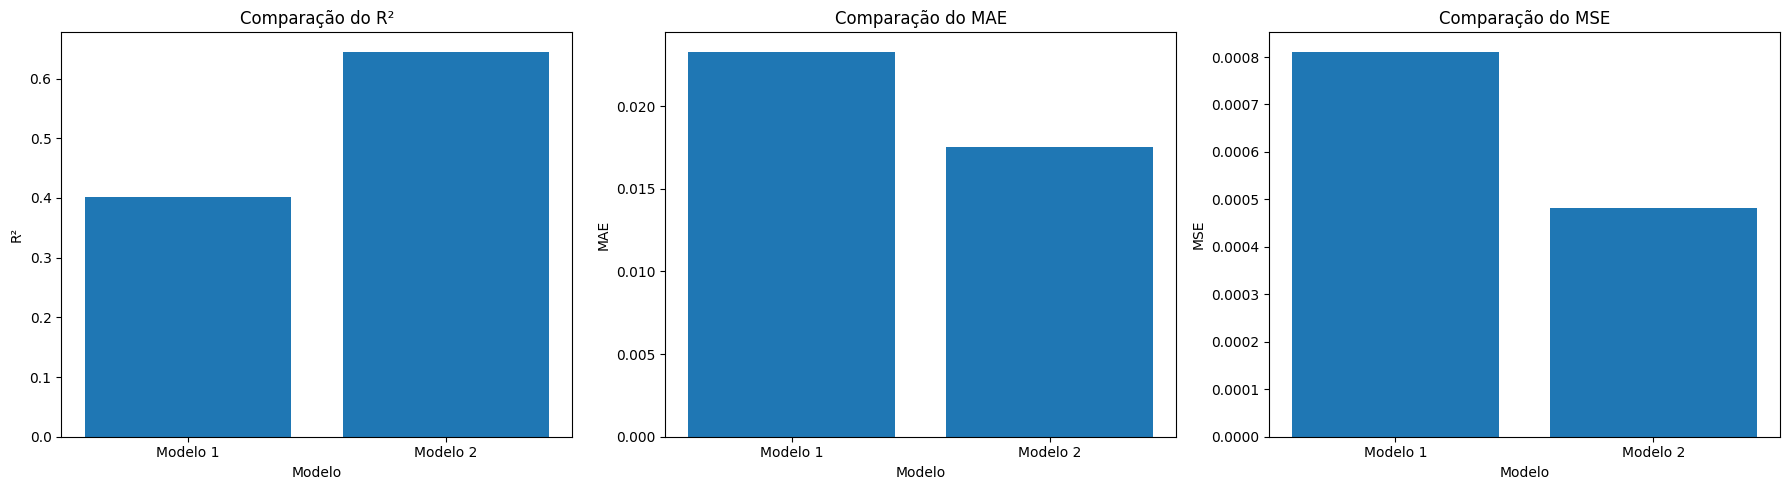

In [ ]:
# Crie os gráficos comparativos das métricas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico R²
axes[0].bar(
    comparacao_modelos['Modelo'],
    comparacao_modelos['R²']
)
axes[0].set_title('Comparação do R²')
axes[0].set_ylabel('R²')
axes[0].set_xlabel('Modelo')

# Gráfico MAE
axes[1].bar(
    comparacao_modelos['Modelo'],
    comparacao_modelos['MAE']
)
axes[1].set_title('Comparação do MAE')
axes[1].set_ylabel('MAE')
axes[1].set_xlabel('Modelo')

# Gráfico MSE
axes[2].bar(
    comparacao_modelos['Modelo'],
    comparacao_modelos['MSE']
)
axes[2].set_title('Comparação do MSE')
axes[2].set_ylabel('MSE')
axes[2].set_xlabel('Modelo')

plt.tight_layout()
plt.show()

## Análise comparativa final

Responda com base na tabela e nos gráficos comparativos.

**1. Qual modelo apresentou o maior R²? Informe os valores dos dois modelos.**  
Resposta:  

**2. Qual modelo apresentou o menor MAE? Informe os valores dos dois modelos.**  
Resposta:  

**3. Qual modelo apresentou o menor MSE? Informe os valores dos dois modelos.**  
Resposta:  

**4. As três métricas indicaram o mesmo modelo como o de melhor desempenho? Justifique comparando os resultados.**  
Resposta:  

**5. O que mudou no desempenho quando as cinco variáveis de maior correlação foram substituídas pelo conjunto completo de variáveis `tau` e `g`?**  
Resposta:  

**6. Considerando os resultados obtidos, qual modelo você escolheria para prever `stab`? Justifique com R², MAE e MSE.**  
Resposta:  

In [ ]:
# Identificar os melhores resultados

modelo_maior_r2 = comparacao_modelos.loc[
    comparacao_modelos['R²'].idxmax(), 'Modelo'
]

modelo_menor_mae = comparacao_modelos.loc[
    comparacao_modelos['MAE'].idxmin(), 'Modelo'
]

modelo_menor_mse = comparacao_modelos.loc[
    comparacao_modelos['MSE'].idxmin(), 'Modelo'
]

print("1. Qual modelo apresentou o maior R²?")
print(f"Resposta: {modelo_maior_r2}.")
print(f"Modelo 1: {r2_modelo_1:.4f}")
print(f"Modelo 2: {r2_modelo_2:.4f}")

print("\n2. Qual modelo apresentou o menor MAE?")
print(f"Resposta: {modelo_menor_mae}.")
print(f"Modelo 1: {mae_modelo_1:.4f}")
print(f"Modelo 2: {mae_modelo_2:.4f}")

print("\n3. Qual modelo apresentou o menor MSE?")
print(f"Resposta: {modelo_menor_mse}.")
print(f"Modelo 1: {mse_modelo_1:.4f}")
print(f"Modelo 2: {mse_modelo_2:.4f}")

print("\n4. As três métricas indicaram o mesmo modelo?")
if modelo_maior_r2 == modelo_menor_mae == modelo_menor_mse:
    print("Resposta: Sim. As três métricas indicaram o mesmo modelo.")
else:
    print("Resposta: Não. As métricas apresentaram resultados diferentes entre os modelos.")

1. Qual modelo apresentou o maior R²?
Resposta: Modelo 2.
Modelo 1: 0.4018
Modelo 2: 0.6452

2. Qual modelo apresentou o menor MAE?
Resposta: Modelo 2.
Modelo 1: 0.0233
Modelo 2: 0.0176

3. Qual modelo apresentou o menor MSE?
Resposta: Modelo 2.
Modelo 1: 0.0008
Modelo 2: 0.0005

4. As três métricas indicaram o mesmo modelo?
Resposta: Sim. As três métricas indicaram o mesmo modelo.


# Conferência e entrega

Antes de entregar, verifique se o notebook contém:

- identificação dos integrantes;
- carregamento e análise inicial do dataset;
- `y` definido com a coluna `stab`;
- matriz de correlação e mapa de calor;
- seleção das cinco maiores correlações absolutas;
- cinco gráficos de dispersão em relação a `stab`;
- Modelo 1 com as cinco variáveis selecionadas;
- Modelo 2 com todas as variáveis `tau` e `g`;
- R², MAE e MSE dos dois modelos;
- tabela e gráficos comparativos das métricas;
- respostas da análise comparativa final;
- todas as células executadas e sem erros.

Salve o arquivo `.ipynb` e faça o upload no **repositório GitHub da atividade criado anteriormente**. Este notebook fará parte do **Checkpoint 2**.